Data Integration & Exploratory Data Analysis

This notebook combines the cleaned collision, vehicle and casualty datasets into a single machine learning dataset.

The main objectives are:

- Load the cleaned datasets.
- Aggregate vehicle and casualty information at collision level.
- Merge all datasets into a single table.
- Perform exploratory data analysis.
- Create a small number of meaningful features.
- Export the final dataset ready for model training.

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Load Clean Datasets

Load the cleaned datasets generated during the previous preparation stage.

These datasets will be combined into a single table where each row represents one collision.

In [3]:
collision = pd.read_csv('/content/drive/MyDrive/PROYECT_1/collision_clean.csv')

In [4]:
vehicle = pd.read_csv('/content/drive/MyDrive/PROYECT_1/vehicle_clean.csv')

In [5]:
casualty = pd.read_csv('/content/drive/MyDrive/PROYECT_1/casualty_clean.csv')

In [6]:
pd.set_option('display.max_columns', None)

In [7]:
collision.head()

,collision_index,collision_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_district,local_authority_ons_district,local_authority_highway,local_authority_highway_current,first_road_class,first_road_number,road_type,speed_limit,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location
0,2018450290294,2018,487906.0,132932.0,-0.746206,51.088970,45,3,2,2,15/04/2018,1,08:00,517,E07000216,E10000030,E10000030,6,0,6,30.0,0,-1,0,-1,0,1,9,1,0,0,1,2,2,E01030927
1,2020230984311,2020,433493.0,258232.0,-1.511123,52.221299,23,2,5,2,21/09/2020,2,23:00,293,E07000221,E10000031,E10000031,1,40,3,70.0,0,-1,0,-1,0,6,1,1,4,13,2,1,1,E01031199
2,2019010177739,2019,536988.0,176455.0,-0.029082,51.470486,1,3,2,1,29/04/2019,2,09:01,7,E09000023,E09000023,E09000023,3,20,6,20.0,19,4,6,0,14,1,1,1,0,0,1,1,2,E01003210
3,2011370225611,2011,654970.0,293400.0,1.753436,52.478868,37,3,2,1,05/06/2011,1,13:05,416,E07000206,E10000029,E10000029,6,0,6,20.0,13,4,6,0,0,1,1,1,0,0,1,1,2,E01030249
4,2013471300464,2013,527289.0,136778.0,-0.182787,51.116101,47,3,1,1,23/01/2013,4,11:00,560,E07000226,E10000032,E10000032,3,2004,3,30.0,0,2,6,0,14,1,1,2,0,0,1,1,2,E01031585


In [8]:
collision.shape

(1886746, 35)

In [9]:
collision.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1886746 entries, 0 to 1886745
Data columns (total 35 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   collision_index                              object 
 1   collision_year                               int64  
 2   location_easting_osgr                        float64
 3   location_northing_osgr                       float64
 4   longitude                                    float64
 5   latitude                                     float64
 6   police_force                                 int64  
 7   collision_severity                           int64  
 8   number_of_vehicles                           int64  
 9   number_of_casualties                         int64  
 10  date                                         object 
 11  day_of_week                                  int64  
 12  time                                         object 
 13  local_author

In [10]:
collision.isnull().sum()

,0
collision_index,0
collision_year,0
location_easting_osgr,201
location_northing_osgr,201
longitude,201
latitude,201
police_force,0
collision_severity,0
number_of_vehicles,0
number_of_casualties,0


In [11]:
vehicle.head()

,collision_index,collision_year,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane,junction_location,skidding_and_overturning,hit_object_in_carriageway,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,vehicle_left_hand_drive,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,2014214000919,2014,2,9,0,19,1,5,0,8,0,0,0,0,1,1,2,2,34,6,998,1,2,PEUGEOT 107,-1,E01010542,0,-1
1,2014554C16552,2014,2,9,0,9,7,5,0,8,0,0,0,0,3,1,6,1,46,8,998,1,3,PEUGEOT 107,-1,E01032660,0,-1
2,201442I094703,2014,4,9,0,3,7,3,0,5,0,0,0,0,2,1,6,1,58,9,998,1,5,PEUGEOT 107,-1,E01021412,0,-1
3,201443W158124,2014,1,9,0,19,6,2,0,0,0,0,0,0,1,1,6,2,-1,-1,998,1,7,PEUGEOT 107,-1,-1,0,-1
4,201406L082426,2014,2,9,0,19,8,4,0,8,0,0,0,0,4,1,6,2,20,4,998,1,1,PEUGEOT 107,-1,E01006253,0,-1


In [12]:
vehicle.shape

(3457626, 28)

In [13]:
vehicle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3457626 entries, 0 to 3457625
Data columns (total 28 columns):
 #   Column                            Dtype 
---  ------                            ----- 
 0   collision_index                   object
 1   collision_year                    int64 
 2   vehicle_reference                 int64 
 3   vehicle_type                      int64 
 4   towing_and_articulation           int64 
 5   vehicle_manoeuvre                 int64 
 6   vehicle_direction_from            int64 
 7   vehicle_direction_to              int64 
 8   vehicle_location_restricted_lane  int64 
 9   junction_location                 int64 
 10  skidding_and_overturning          int64 
 11  hit_object_in_carriageway         int64 
 12  vehicle_leaving_carriageway       int64 
 13  hit_object_off_carriageway        int64 
 14  first_point_of_impact             int64 
 15  vehicle_left_hand_drive           int64 
 16  journey_purpose_of_driver         int64 
 17  sex_of_d

In [14]:
vehicle.isnull().sum()

,0
collision_index,0
collision_year,0
vehicle_reference,0
vehicle_type,0
towing_and_articulation,0
vehicle_manoeuvre,0
vehicle_direction_from,0
vehicle_direction_to,0
vehicle_location_restricted_lane,0
junction_location,0


Vehicle Aggregation

The vehicle dataset contains one row per vehicle. To create a collision-level dataset, vehicle information is aggregated using summary statistics such as average driver age, vehicle age and the most common vehicle type.

In [15]:
vehicle_summary = (
    vehicle.groupby('collision_index').agg(
        average_driver_age = ('age_of_driver', 'mean'),
        max_driver_age = ('age_of_driver', 'max'),
        average_vehicle_age = ('age_of_vehicle', 'mean'),
        max_vehicle_age = ('age_of_vehicle', 'max'),
        left_hand_driving = ('vehicle_left_hand_drive', 'sum'),
        most_common_vehicle_type = ('vehicle_type', lambda x: x.mode().iloc[0])
        ).reset_index()
)

In [16]:
casualty.head()

,collision_index,collision_year,collision_ref_no,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,casualty_severity,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,lsoa_of_casualty,enhanced_casualty_severity,casualty_injury_based,casualty_adjusted_severity_serious,casualty_adjusted_severity_slight,casualty_distance_banding
0,201014A106410,2010,14A106410,1,1,3,1,8,2,3,5,4,0,0,0,0,-1,-1,-1,0,0.11314,0.88686,-1
1,2010331003800,2010,331003800,2,1,1,1,12,3,3,0,0,0,0,0,1,-1,E01025786,-1,0,0.02543,0.97457,-1
2,2010521008537,2010,521008537,1,1,1,2,55,8,3,0,0,0,0,0,9,-1,E01029088,-1,0,0.02017,0.97983,-1
3,201043W163070,2010,43W163070,2,1,1,2,19,4,3,0,0,0,0,0,9,-1,E01016471,-1,0,0.00708,0.99292,-1
4,2010521009474,2010,521009474,1,1,1,2,38,7,3,0,0,0,0,0,5,-1,E01014723,-1,0,0.05171,0.94829,-1


In [17]:
casualty.shape

(2479311, 23)

In [18]:
casualty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2479311 entries, 0 to 2479310
Data columns (total 23 columns):
 #   Column                              Dtype  
---  ------                              -----  
 0   collision_index                     object 
 1   collision_year                      int64  
 2   collision_ref_no                    object 
 3   vehicle_reference                   int64  
 4   casualty_reference                  int64  
 5   casualty_class                      int64  
 6   sex_of_casualty                     int64  
 7   age_of_casualty                     int64  
 8   age_band_of_casualty                int64  
 9   casualty_severity                   int64  
 10  pedestrian_location                 int64  
 11  pedestrian_movement                 int64  
 12  car_passenger                       int64  
 13  bus_or_coach_passenger              int64  
 14  pedestrian_road_maintenance_worker  int64  
 15  casualty_type                       int64  
 16  

In [19]:
casualty.isnull().sum()

,0
collision_index,0
collision_year,0
collision_ref_no,0
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,0
age_of_casualty,0
age_band_of_casualty,0
casualty_severity,0


Casualty Aggregation

The casualty dataset contains one row per casualty. The information is aggregated at collision level to generate variables describing the people involved in each collision.

In [20]:
casualty_summary = (casualty.groupby('collision_index').agg(
    average_casualty_age = ('age_of_casualty', 'mean'),
    max_casualty_age = ('age_of_casualty', 'max'),
    casualty_count = ('casualty_reference', 'count'),
    pedestrian_count = ('casualty_type', lambda x: (x == 0).sum()),
    most_common_casualty_type = ('casualty_type', lambda x: x.mode().iloc[0])
).reset_index()
)

Merge Datasets

Merge the collision, vehicle and casualty datasets using the collision identifier.

The resulting dataset contains one row per collision and combines information from all three sources.

In [21]:
df = collision.merge(
    vehicle_summary,
    on = 'collision_index',
    how = 'left'
)

In [22]:
df = df.merge(
    casualty_summary,
    on = 'collision_index',
    how = 'left'
)

In [23]:
df.shape

(1886746, 46)

In [24]:
df.head()

,collision_index,collision_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,date,day_of_week,time,local_authority_district,local_authority_ons_district,local_authority_highway,local_authority_highway_current,first_road_class,first_road_number,road_type,speed_limit,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,average_driver_age,max_driver_age,average_vehicle_age,max_vehicle_age,left_hand_driving,most_common_vehicle_type,average_casualty_age,max_casualty_age,casualty_count,pedestrian_count,most_common_casualty_type
0,2018450290294,2018,487906.0,132932.0,-0.746206,51.088970,45,3,2,2,15/04/2018,1,08:00,517,E07000216,E10000030,E10000030,6,0,6,30.0,0,-1,0,-1,0,1,9,1,0,0,1,2,2,E01030927,37.0,48,5.5,6,2,9,37.0,48,2,0,9
1,2020230984311,2020,433493.0,258232.0,-1.511123,52.221299,23,2,5,2,21/09/2020,2,23:00,293,E07000221,E10000031,E10000031,1,40,3,70.0,0,-1,0,-1,0,6,1,1,4,13,2,1,1,E01031199,49.2,64,6.4,14,5,21,42.0,48,2,0,9
2,2019010177739,2019,536988.0,176455.0,-0.029082,51.470486,1,3,2,1,29/04/2019,2,09:01,7,E09000023,E09000023,E09000023,3,20,6,20.0,19,4,6,0,14,1,1,1,0,0,1,1,2,E01003210,46.0,48,7.5,12,2,5,48.0,48,1,0,5
3,2011370225611,2011,654970.0,293400.0,1.753436,52.478868,37,3,2,1,05/06/2011,1,13:05,416,E07000206,E10000029,E10000029,6,0,6,20.0,13,4,6,0,0,1,1,1,0,0,1,1,2,E01030249,22.0,45,-1.0,-1,2,1,45.0,45,1,0,1
4,2013471300464,2013,527289.0,136778.0,-0.182787,51.116101,47,3,1,1,23/01/2013,4,11:00,560,E07000226,E10000032,E10000032,3,2004,3,30.0,0,2,6,0,14,1,1,2,0,0,1,1,2,E01031585,63.0,63,3.0,3,1,9,21.0,21,1,1,0


In [25]:
df.rename(columns={'left_hand_driving': 'left_hand_drive_count'}, inplace=True)

Feature Engineering

Create additional variables that may improve model performance.

The engineered features include temporal information such as:

- Hour
- Month
- Season
- Weekend
- Rush Hour

In [26]:
df['hour'] = pd.to_datetime(df['time'], format='%H:%M').dt.hour

In [27]:
df['hour'].value_counts()

,count
hour,
17,167156
16,154457
15,148423
18,133448
8,132161
14,116930
13,113102
12,110087
19,99077


In [28]:
df.drop('time',axis=1,inplace=True)

In [29]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

In [30]:
df['month'] = df['date'].dt.month

In [31]:
df.head()

,collision_index,collision_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,date,day_of_week,local_authority_district,local_authority_ons_district,local_authority_highway,local_authority_highway_current,first_road_class,first_road_number,road_type,speed_limit,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,average_driver_age,max_driver_age,average_vehicle_age,max_vehicle_age,left_hand_drive_count,most_common_vehicle_type,average_casualty_age,max_casualty_age,casualty_count,pedestrian_count,most_common_casualty_type,hour,month
0,2018450290294,2018,487906.0,132932.0,-0.746206,51.088970,45,3,2,2,2018-04-15,1,517,E07000216,E10000030,E10000030,6,0,6,30.0,0,-1,0,-1,0,1,9,1,0,0,1,2,2,E01030927,37.0,48,5.5,6,2,9,37.0,48,2,0,9,8,4
1,2020230984311,2020,433493.0,258232.0,-1.511123,52.221299,23,2,5,2,2020-09-21,2,293,E07000221,E10000031,E10000031,1,40,3,70.0,0,-1,0,-1,0,6,1,1,4,13,2,1,1,E01031199,49.2,64,6.4,14,5,21,42.0,48,2,0,9,23,9
2,2019010177739,2019,536988.0,176455.0,-0.029082,51.470486,1,3,2,1,2019-04-29,2,7,E09000023,E09000023,E09000023,3,20,6,20.0,19,4,6,0,14,1,1,1,0,0,1,1,2,E01003210,46.0,48,7.5,12,2,5,48.0,48,1,0,5,9,4
3,2011370225611,2011,654970.0,293400.0,1.753436,52.478868,37,3,2,1,2011-06-05,1,416,E07000206,E10000029,E10000029,6,0,6,20.0,13,4,6,0,0,1,1,1,0,0,1,1,2,E01030249,22.0,45,-1.0,-1,2,1,45.0,45,1,0,1,13,6
4,2013471300464,2013,527289.0,136778.0,-0.182787,51.116101,47,3,1,1,2013-01-23,4,560,E07000226,E10000032,E10000032,3,2004,3,30.0,0,2,6,0,14,1,1,2,0,0,1,1,2,E01031585,63.0,63,3.0,3,1,9,21.0,21,1,1,0,11,1


In [32]:
df['day_of_week'].value_counts()

,count
day_of_week,
6,309602
5,287131
4,283210
3,280530
2,266445
7,251216
1,208612


In [33]:
df['weekend'] = (
    df['day_of_week'].isin([1,7]).astype(int)
)

In [34]:
df['weekend'].value_counts()

,count
weekend,
0,1426918
1,459828


In [35]:
rush = [7,8,9,16,17,18]

df['rush_hour'] = (
    df['hour'].isin(rush).astype(int)
)

In [36]:
df['rush_hour'].value_counts()

,count
rush_hour,
0,1127680
1,759066


In [37]:
def get_season(month):
  if month in [12,1,2]:
    return 'Winter'
  elif month in [3,4,5]:
    return 'Spring'
  elif month in [6,7,8]:
    return 'Summer'
  else:
    return 'Autumn'

In [38]:
df['season'] = df['month'].apply(get_season)

In [39]:
df['season'].value_counts()

,count
season,
Autumn,508018
Summer,486034
Spring,448385
Winter,444309


In [40]:
df.drop('date',axis=1,inplace=True)

In [41]:
df.shape

(1886746, 49)

In [42]:
df.head()

,collision_index,collision_year,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,day_of_week,local_authority_district,local_authority_ons_district,local_authority_highway,local_authority_highway_current,first_road_class,first_road_number,road_type,speed_limit,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,average_driver_age,max_driver_age,average_vehicle_age,max_vehicle_age,left_hand_drive_count,most_common_vehicle_type,average_casualty_age,max_casualty_age,casualty_count,pedestrian_count,most_common_casualty_type,hour,month,weekend,rush_hour,season
0,2018450290294,2018,487906.0,132932.0,-0.746206,51.088970,45,3,2,2,1,517,E07000216,E10000030,E10000030,6,0,6,30.0,0,-1,0,-1,0,1,9,1,0,0,1,2,2,E01030927,37.0,48,5.5,6,2,9,37.0,48,2,0,9,8,4,1,1,Spring
1,2020230984311,2020,433493.0,258232.0,-1.511123,52.221299,23,2,5,2,2,293,E07000221,E10000031,E10000031,1,40,3,70.0,0,-1,0,-1,0,6,1,1,4,13,2,1,1,E01031199,49.2,64,6.4,14,5,21,42.0,48,2,0,9,23,9,0,0,Autumn
2,2019010177739,2019,536988.0,176455.0,-0.029082,51.470486,1,3,2,1,2,7,E09000023,E09000023,E09000023,3,20,6,20.0,19,4,6,0,14,1,1,1,0,0,1,1,2,E01003210,46.0,48,7.5,12,2,5,48.0,48,1,0,5,9,4,0,1,Spring
3,2011370225611,2011,654970.0,293400.0,1.753436,52.478868,37,3,2,1,1,416,E07000206,E10000029,E10000029,6,0,6,20.0,13,4,6,0,0,1,1,1,0,0,1,1,2,E01030249,22.0,45,-1.0,-1,2,1,45.0,45,1,0,1,13,6,1,0,Summer
4,2013471300464,2013,527289.0,136778.0,-0.182787,51.116101,47,3,1,1,4,560,E07000226,E10000032,E10000032,3,2004,3,30.0,0,2,6,0,14,1,1,2,0,0,1,1,2,E01031585,63.0,63,3.0,3,1,9,21.0,21,1,1,0,11,1,0,0,Winter


In [43]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
local_authority_highway_current,287
latitude,201
location_easting_osgr,201
longitude,201
location_northing_osgr,201
collision_index,0
collision_year,0
collision_severity,0
police_force,0
number_of_vehicles,0


**Exploratory Data Analysis**

Dataset Overview

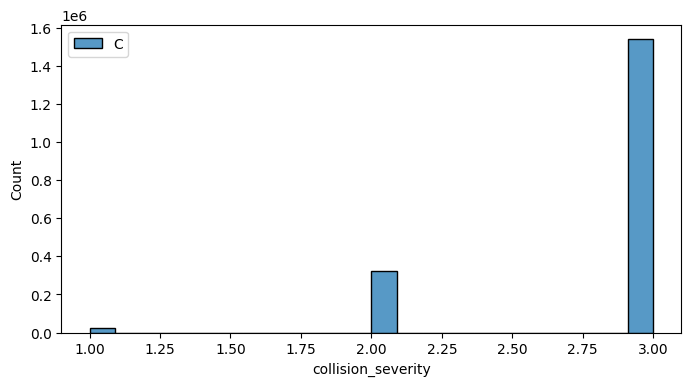

In [44]:
plt.figure(figsize=(8,4))
sns.histplot(df['collision_severity'])
plt.legend('Collision Severity')
plt.show()

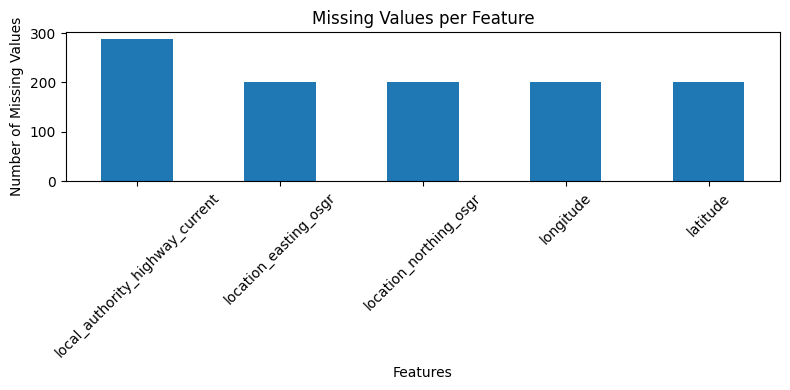

In [45]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8,4))

missing.plot(kind="bar")

plt.title("Missing Values per Feature")
plt.ylabel("Number of Missing Values")
plt.xlabel("Features")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Temporal Analysis

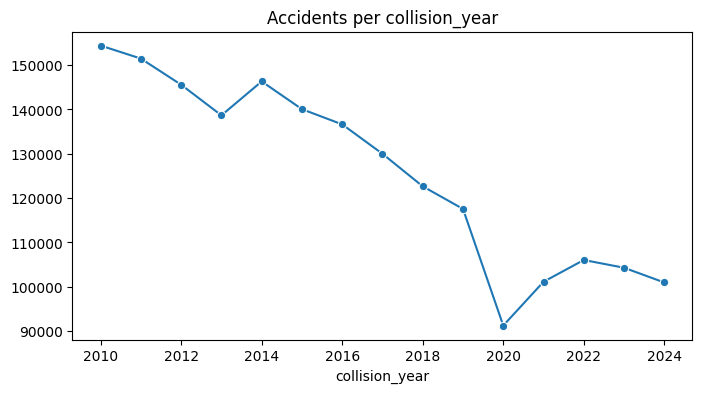

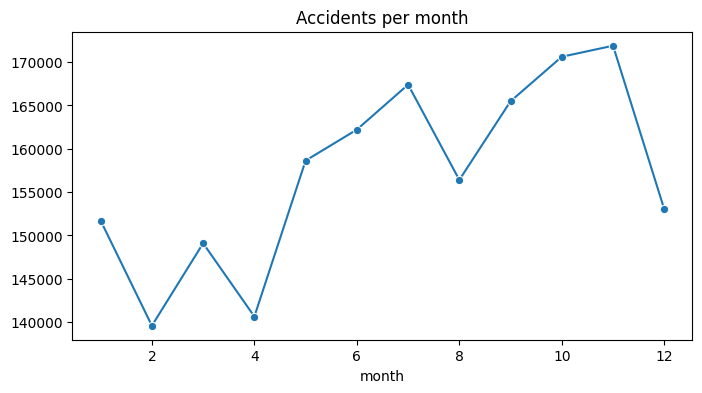

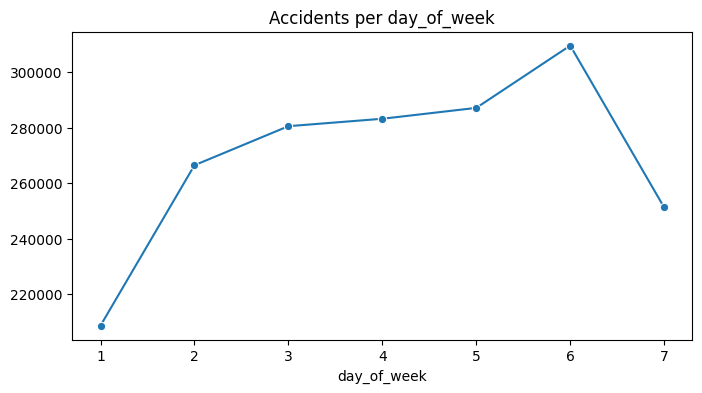

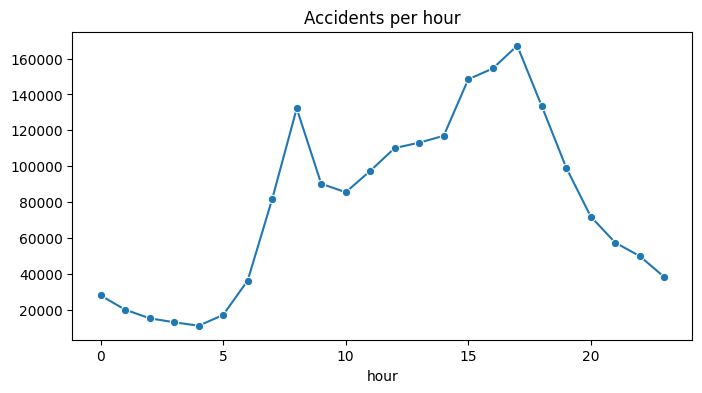

In [70]:
temporal_features = ['collision_year', 'month', 'day_of_week', 'hour']

for i in temporal_features:
    plt.figure(figsize=(8, 4))
    counts = df[i].value_counts().sort_index()
    sns.lineplot(x=counts.index, y=counts.values, marker='o')
    plt.title(f'Accidents per {i}')
    plt.show()

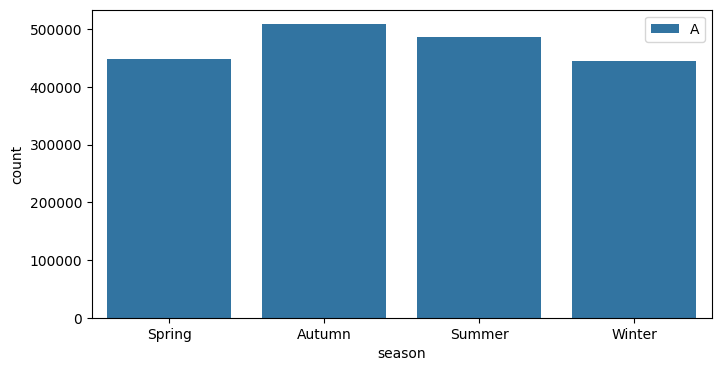

In [47]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='season')
plt.legend('Accidents per Season')
plt.show()

Environmental Analysis

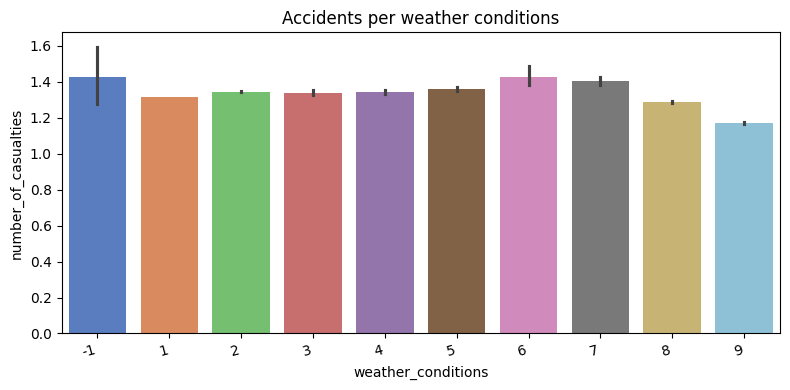

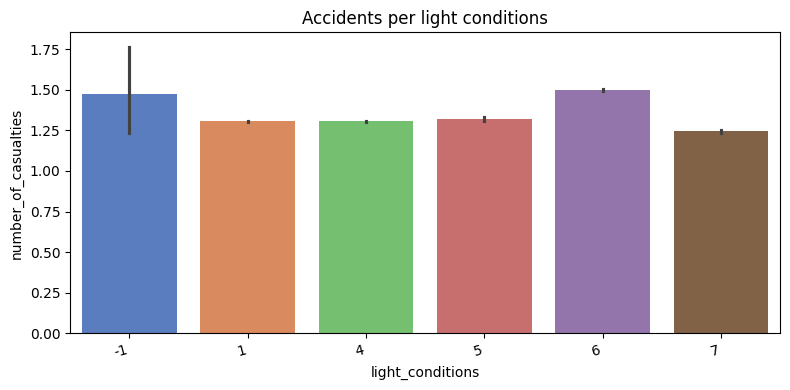

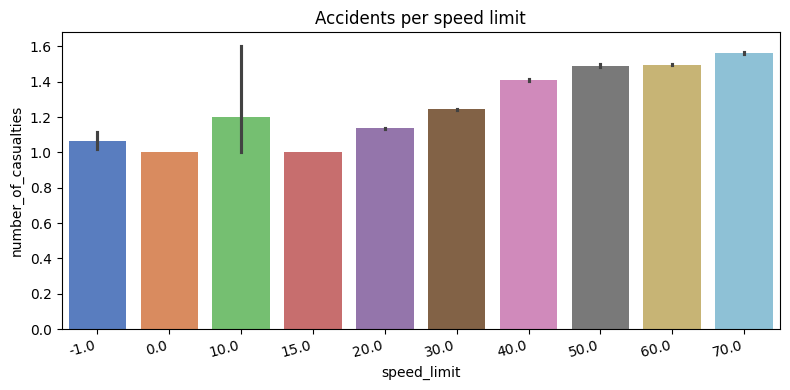

In [69]:
environmental_conds = ['weather_conditions', 'light_conditions', 'speed_limit']
for i in environmental_conds:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=df, x=i, y='number_of_casualties', palette='muted', hue=i, legend=False)
    plt.title(f'Accidents per {i.replace("_", " ")}')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()

Driver and Casualty Analysis

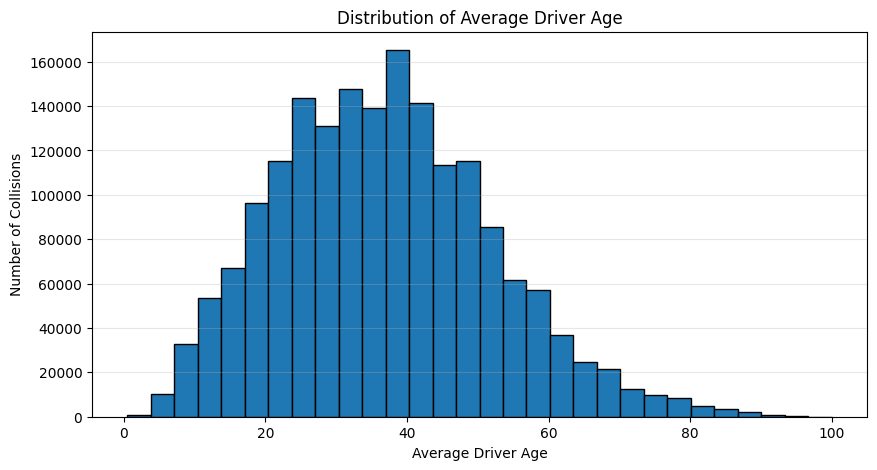

In [59]:
driver_age = df[df["average_driver_age"] >= 0]["average_driver_age"]

plt.figure(figsize=(10, 5))

plt.hist(
    driver_age,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Average Driver Age")
plt.xlabel("Average Driver Age")
plt.ylabel("Number of Collisions")

plt.grid(axis="y", alpha=0.3)

plt.show()

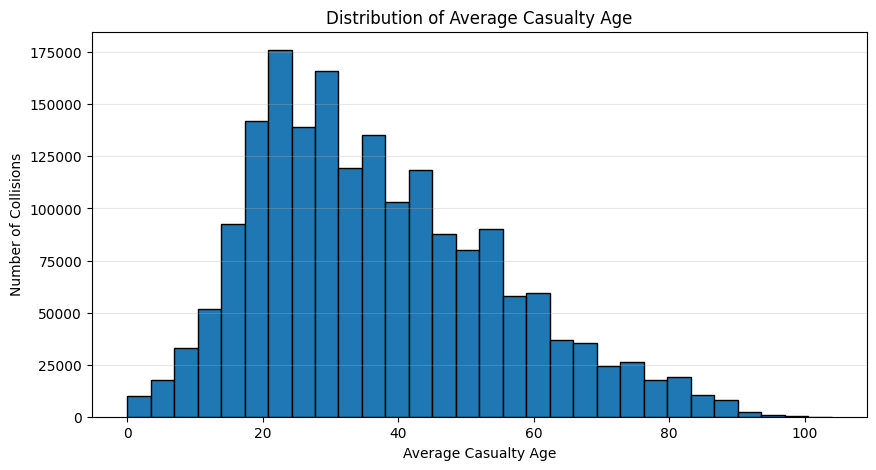

In [60]:
casualty_age = df[df["average_casualty_age"] >= 0]["average_casualty_age"]

plt.figure(figsize=(10, 5))

plt.hist(
    casualty_age,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Average Casualty Age")
plt.xlabel("Average Casualty Age")
plt.ylabel("Number of Collisions")

plt.grid(axis="y", alpha=0.3)

plt.show()

Correlation Analysis

Correlation Matrix

Analyse the linear relationship between the main numerical variables in the dataset. The correlation matrix helps identify highly correlated features that may influence model performance or indicate redundant information.

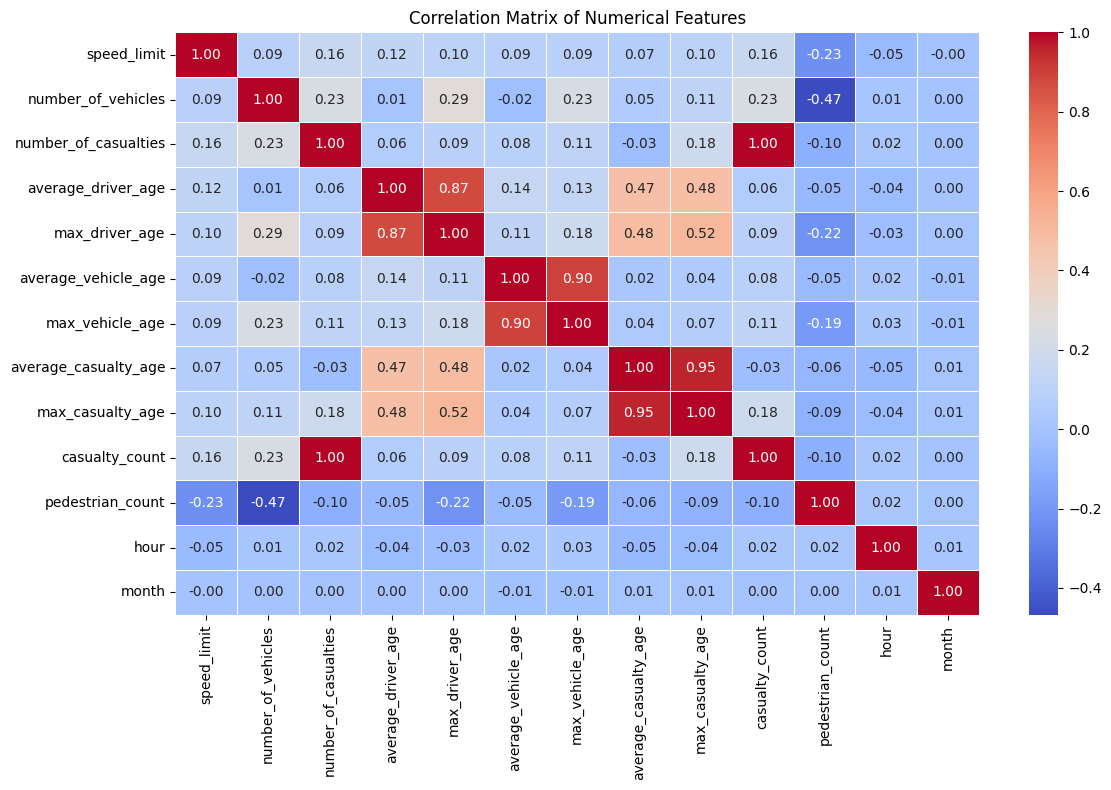

In [63]:
numerical_features = [
    "speed_limit",
    "number_of_vehicles",
    "number_of_casualties",
    "average_driver_age",
    "max_driver_age",
    "average_vehicle_age",
    "max_vehicle_age",
    "average_casualty_age",
    "max_casualty_age",
    "casualty_count",
    "pedestrian_count",
    "hour",
    "month"
]

corr = df[numerical_features].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()

plt.show()

Correlation with Collision Severity

Measure the relationship between the numerical features and the target variable. Although correlation does not imply causation, this analysis provides an initial indication of which numerical variables may be associated with collision severity.

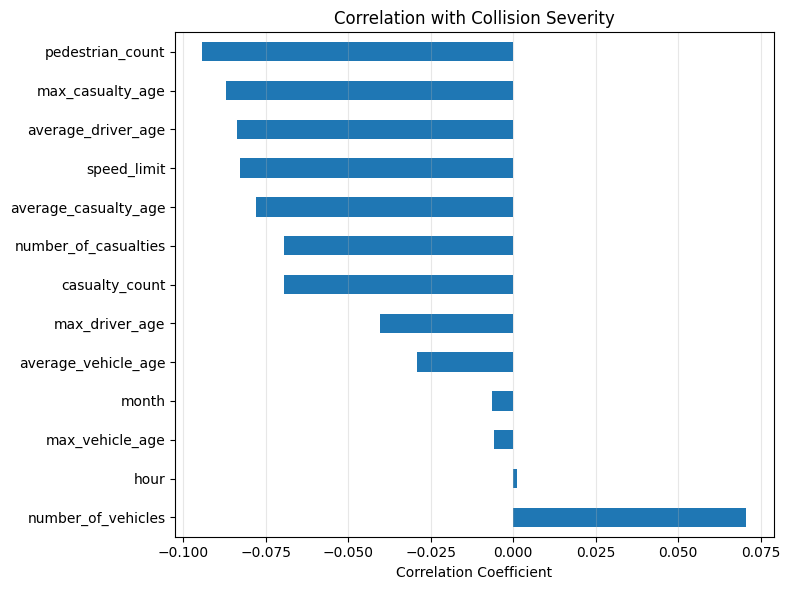

In [64]:
target_corr = (
    df[numerical_features + ["collision_severity"]]
    .corr()["collision_severity"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))

target_corr.drop("collision_severity").plot(
    kind="barh"
)

plt.title("Correlation with Collision Severity")
plt.xlabel("Correlation Coefficient")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

Save Final Dataset

Export the processed machine learning dataset. This dataset will be used during model training and evaluation.

In [65]:
df.to_csv('model_dataset.csv',index=False)

The three cleaned datasets were successfully integrated into a single machine learning dataset.

Summary of the work completed:

- Aggregated vehicle information at collision level.
- Aggregated casualty information at collision level.
- Merged the three cleaned datasets.
- Created additional temporal features.
- Performed exploratory data analysis.
- Verified the quality of the final dataset.
- Exported the processed dataset ready for model training.

In [66]:
print('Final Dataset Summary')
print('='*50)
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print(f'Missing Values: {df.isnull().sum().sum()}')
print(f'Duplicate Rows: {df.duplicated().sum()}')

Final Dataset Summary
Rows: 1886746
Columns: 49
Missing Values: 1091
Duplicate Rows: 0
